In [1]:
import pandas as pd
import glob
import os
import re
import sys
from omegaconf import OmegaConf

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

data = pd.read_pickle('validated_final_df_57344_imputed.pkl')
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

### Fitting a Random Forest to predict the sum of the voltages

In [9]:
import time
import pickle
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# === 0) Prepare data X, y ===
target_cols = [f"Ucell_{i}" for i in range(30)]

# Replace negative values with 0
data_cleaned = data.copy()
data_cleaned[target_cols] = data_cleaned[target_cols].clip(lower=0)

# Compute target as the sum across target_cols
X = data_cleaned[parameter_ranges].values
y = data_cleaned[target_cols].sum(axis=1).values

# === 1) Scale once up front ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 2) Define outer/inner CV ===
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# === 3) RF + grid for inner tuning ===
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators':     [100, 200, 500],
    'max_depth':        [None, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

inner_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# === 4) Outer loop: tune & test ===
outer_mse = []
outer_r2  = []
best_params = []

# Track best model across all folds
best_overall_model = None
lowest_mse = float('inf')

start = time.time()
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_scaled, y), 1):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    inner_search.fit(X_train, y_train)
    best_params.append(inner_search.best_params_)

    best_model = inner_search.best_estimator_
    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    outer_mse.append(mse)
    outer_r2.append(r2)

    print(f"Fold {fold} → Best inner MSE: {-inner_search.best_score_:.4f}, "
          f"Test MSE: {mse:.4f}, Test R²: {r2:.4f}")

    # Check if this is the best model so far
    if mse < lowest_mse:
        lowest_mse = mse
        best_overall_model = best_model

elapsed = time.time() - start
print(f"\n✅ Nested CV done in {elapsed:.1f}s")

# === 5) Save only the best overall model ===
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_overall_model, f)
print("Best overall model saved to best_model.pkl")

# === 6) Summaries ===
print(f"\nAvg outer‐fold MSE: {np.mean(outer_mse):.4f} ± {np.std(outer_mse):.4f}")
print(f"Avg outer‐fold R²:  {np.mean(outer_r2):.4f} ± {np.std(outer_r2):.4f}")

print("\nBest params per fold:")
for i, p in enumerate(best_params, 1):
    print(f" Fold {i}: {p}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fold 1 → Best inner MSE: 4.9309, Test MSE: 4.2847, Test R²: 0.7690
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fold 2 → Best inner MSE: 4.8853, Test MSE: 4.7578, Test R²: 0.7512
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fold 3 → Best inner MSE: 4.7997, Test MSE: 4.6435, Test R²: 0.7385
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fold 4 → Best inner MSE: 4.9056, Test MSE: 4.7670, Test R²: 0.7522
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fold 5 → Best inner MSE: 4.8556, Test MSE: 4.6355, Test R²: 0.7384

✅ Nested CV done in 4640.7s
Best overall model saved to best_model.pkl

Avg outer‐fold MSE: 4.6177 ± 0.1754
Avg outer‐fold R²:  0.7499 ± 0.0113

Best params per fold:
 Fold 1: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}
 Fold 2: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 500}
 Fold 3: {'max_depth': None, 'min_samples_leaf

Get the Feature Importance of the Random Forest with shap

        feature  importance
0      i0_c_ref    1.339481
1        Pa_des    0.991442
2           Tfc    0.976321
3           tau    0.756127
4       kappa_c    0.731033
5            Re    0.537598
6    epsilon_mc    0.350724
7     Phi_c_des    0.231271
8            Sc    0.183329
9      kappa_co    0.139681
10  epsilon_gdl    0.106050
11    epsilon_c    0.102400
12            e    0.031208


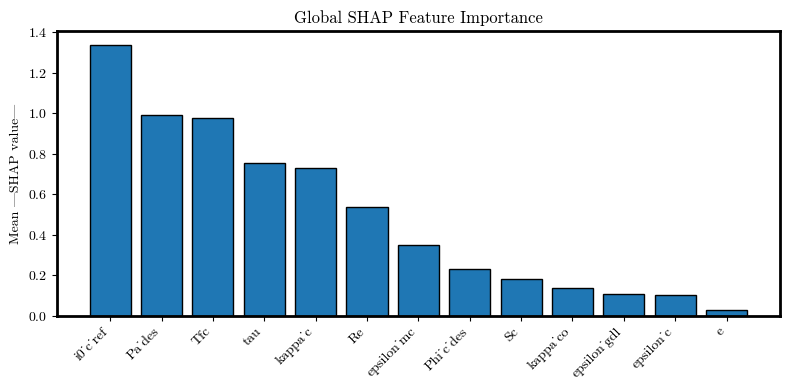

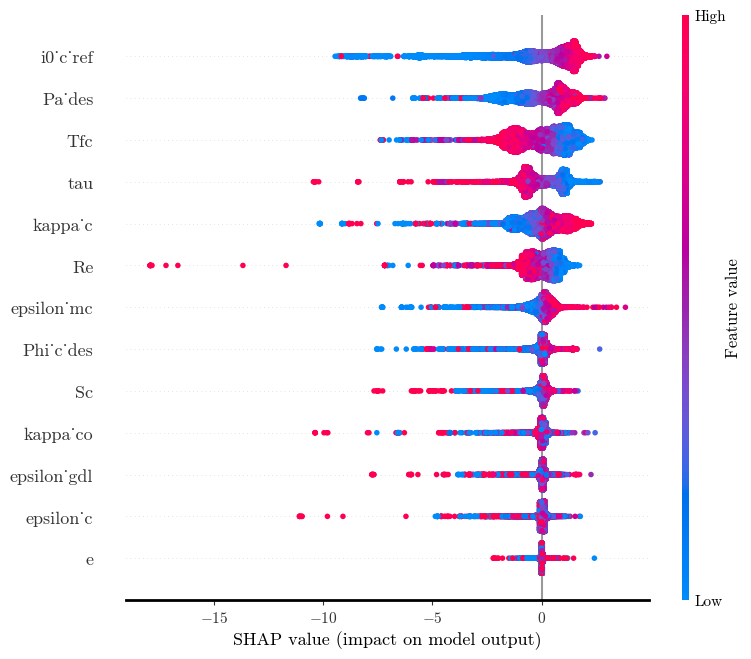

In [3]:
import pickle
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- Load the model ---
with open('best_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

# === 0) Prepare data X, y ===
target_cols = [f"Ucell_{i}" for i in range(30)]

# Replace negative values with 0
data_cleaned = data.copy()
data_cleaned[target_cols] = data_cleaned[target_cols].clip(lower=0)

# Compute target as the sum across target_cols
X = data_cleaned[parameter_ranges].values
y = data_cleaned[target_cols].sum(axis=1).values

# --- Your feature names ---
features = list(parameter_ranges)

# --- Fit and transform scaler ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Build a TreeExplainer on the RF ---
explainer = shap.TreeExplainer(rf_model)

# --- Compute SHAP values on the sample ---
shap_values = explainer.shap_values(X_scaled, approximate=True)

# --- Compute global importances ---
importances = np.mean(np.abs(shap_values), axis=0)
df_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# --- Print the table ---
print(df_imp)

# --- Bar plot of global SHAP importances ---
plt.figure(figsize=(8,4))
plt.bar(df_imp["feature"], df_imp["importance"], edgecolor='k')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean |SHAP value|")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

# --- Beeswarm plot (optional) ---
shap.summary_plot(shap_values, X_scaled, feature_names=features)


In [4]:
import numpy as np
from tqdm import tqdm

n_boot = 100
n_samples = X_scaled.shape[0]
all_importances = []

for _ in tqdm(range(n_boot)):
    idx = np.random.choice(n_samples, size=n_samples, replace=True)
    shap_values_boot = explainer.shap_values(X_scaled[idx], approximate=True)
    imp_boot = np.mean(np.abs(shap_values_boot), axis=0)
    all_importances.append(imp_boot)

all_importances = np.stack(all_importances)  # shape (n_boot, n_features)

# Compute mean & 95% CI
mean_imp = np.mean(all_importances, axis=0)
lower = np.percentile(all_importances, 2.5, axis=0)
upper = np.percentile(all_importances, 97.5, axis=0)

df_ci = pd.DataFrame({
    "feature": features,
    "mean_importance": mean_imp,
    "ci_lower": lower,
    "ci_upper": upper
}).sort_values("mean_importance", ascending=False)

print(df_ci)


100%|██████████| 100/100 [1:08:39<00:00, 41.20s/it]

        feature  mean_importance  ci_lower  ci_upper
10     i0_c_ref         1.339628  1.330458  1.349806
1        Pa_des         0.991654  0.987860  0.997022
0           Tfc         0.976448  0.972555  0.980390
5           tau         0.755761  0.752291  0.759595
12      kappa_c         0.731403  0.726356  0.736349
9            Re         0.537544  0.534143  0.541563
6    epsilon_mc         0.350670  0.347676  0.353338
3     Phi_c_des         0.231345  0.228742  0.234079
2            Sc         0.183587  0.181187  0.185743
11     kappa_co         0.139636  0.137999  0.141689
4   epsilon_gdl         0.106030  0.104368  0.107954
7     epsilon_c         0.102348  0.100666  0.104975
8             e         0.031180  0.030548  0.031685


Create Ucell regions

In [7]:
# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer

# Replace negative values with 0
data_cleaned = data.copy()
data_cleaned[target_cols] = data_cleaned[target_cols].clip(lower=0)
df = data_cleaned
df['Ucell'] = df[target_cols].apply(list, axis=1)
SA = SensitivityAnalyzer(parameter_ranges=parameter_ranges)
df['Ucell_regions'] = SA.aggregate_output_function(df, aggregation_method='sum', by_regions=True)


### Fit a RF for each region (regions aggregated using the sum) and calculate shap

Region 1: CV R² = 0.7815 ± 0.0145


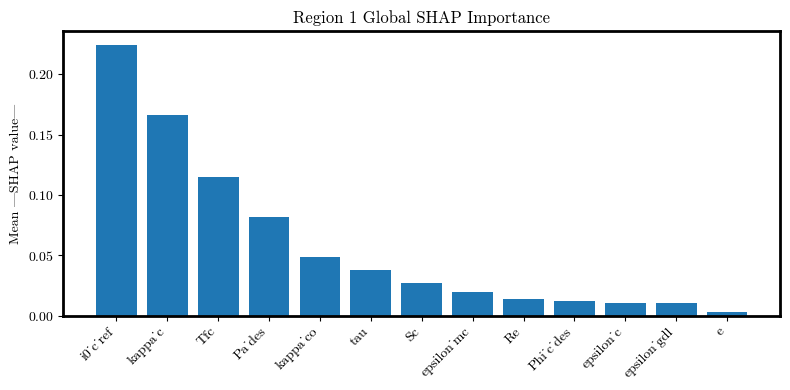

Region 2: CV R² = 0.7120 ± 0.0107


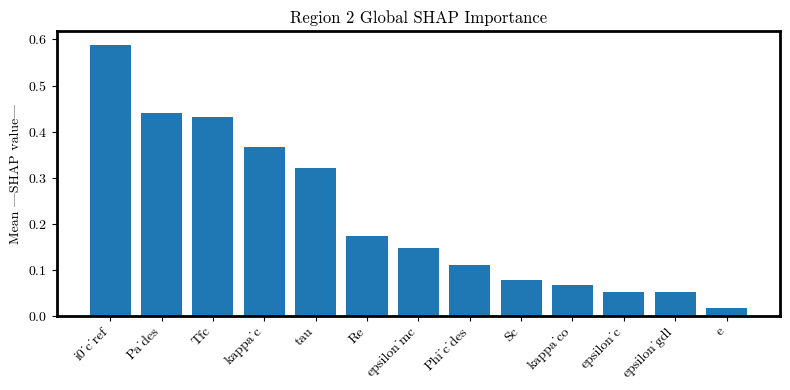

Region 3: CV R² = 0.7312 ± 0.0080


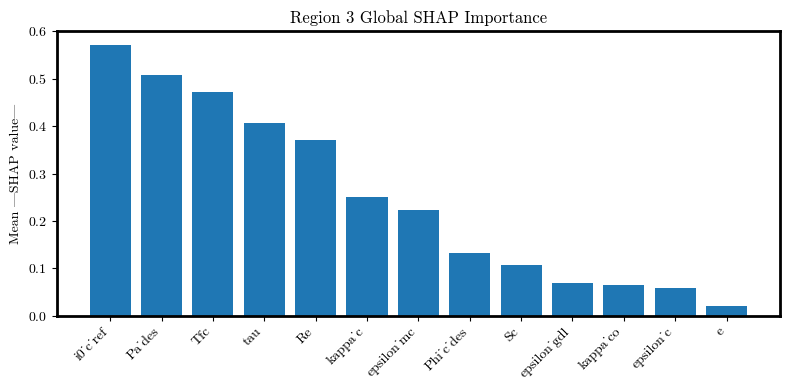

In [8]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Assumes df, parameter_ranges, and Y array are defined as:
X = df[parameter_ranges].values   # shape (n_samples, n_features)
Y = np.stack(df['Ucell_regions']) # shape (n_samples, 3)

# Configuration
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
shap_importances = {region: [] for region in range(3)}  # store per-fold importances
region_r2 = {region: [] for region in range(3)}

# Perform CV
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    # Split
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Loop over regions
    for region in range(3):
        # Train RF
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train_scaled, Y_train[:, region])
        
        # Evaluate R2
        y_pred = rf.predict(X_test_scaled)
        region_r2[region].append(r2_score(Y_test[:, region], y_pred))
        
        # Compute SHAP on test fold
        explainer = shap.TreeExplainer(rf)
        shap_vals = explainer.shap_values(X_test_scaled, approximate=True)
        mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
        shap_importances[region].append(mean_abs_shap)
        
# Aggregate and plot
for region in range(3):
    # Average importances over folds
    imp_array = np.vstack(shap_importances[region])
    avg_imp = np.mean(imp_array, axis=0)
    df_imp = pd.DataFrame({
        'feature': parameter_ranges,
        'mean_abs_shap': avg_imp
    }).sort_values('mean_abs_shap', ascending=False)
    
    # Print performance
    mean_r2 = np.mean(region_r2[region])
    std_r2  = np.std(region_r2[region])
    print(f"Region {region+1}: CV R² = {mean_r2:.4f} ± {std_r2:.4f}")
    
    # Plot bar chart
    plt.figure(figsize=(8, 4))
    plt.bar(df_imp['feature'], df_imp['mean_abs_shap'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Mean |SHAP value|')
    plt.title(f'Region {region+1} Global SHAP Importance')
    plt.tight_layout()
    plt.show()
